---
title: "Bayesian Regression (Stan-free) & Uncertainty"
teaching: 30
exercises: 20
---

# Bayesian Regression (Stan-free) & Uncertainty

In this lesson we introduce **Bayesian linear regression** and **uncertainty quantification** **without** external PPLs (no Stan). We use:
- A **closed-form** Bayesian linear regression under conjugate priors (Normal prior on coefficients),
- A practical **bootstrap** approximation to predictive uncertainty.

We compare intervals to OLS and discuss when each approach is appropriate.

**Learning objectives**
- Derive and implement a **closed-form** Bayesian linear regression in NumPy.
- Compute **credible** and **predictive** intervals via posterior sampling.
- Use **bootstrap** resampling to approximate predictive uncertainty.
- Compare OLS CIs vs Bayesian CrIs; understand their interpretations.



## Bayesian Linear Regression (Conjugate, Stan-free)

Assume the standard linear model
$$
\mathbf{y} \mid X, \boldsymbol{\beta}, \sigma^2 \sim \mathcal{N}(X\boldsymbol{\beta}, \ \sigma^2 I_n),
$$
with a **Gaussian prior** on coefficients (ridge-like prior)
$$
\boldsymbol{\beta} \sim \mathcal{N}\!\left(\mathbf{0}, \ \tau^2 I_p\right).
$$

If we **treat $\sigma^2$ as known** (or plug in an estimate), the **posterior** for $\boldsymbol{\beta}$ is Gaussian:
$$
\Sigma_{\text{post}} \;=\; \left(\frac{1}{\sigma^2}X^\top X \;+\; \frac{1}{\tau^2}I_p \right)^{-1}, \qquad
\boldsymbol{\beta}_{\text{post}} \;=\; \Sigma_{\text{post}} \left(\frac{1}{\sigma^2}X^\top \mathbf{y}\right).
$$

For a new sample $x_\*$, the **posterior predictive** distribution is approximately
$$
y_\* \mid x_\*, \mathcal{D} \ \sim\ \mathcal{N}\!\Big(x_\*^\top \boldsymbol{\beta}_{\text{post}},\ \underbrace{\sigma^2}_{\text{noise}} \;+\; \underbrace{x_\*^\top \Sigma_{\text{post}} x_\*}_{\text{parameter uncertainty}}\Big).
$$

> In practice, we will **estimate $\sigma^2$** from OLS residuals (empirical Bayes). This keeps the implementation simple and fast for teaching purposes.


In [20]:
# Load Diabetes dataset and build OLS baseline
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Data
data = load_diabetes(as_frame=True)
df = data.frame.copy()
df.rename(columns={'target': 'disease_progression'}, inplace=True)

X = df.drop(columns=['disease_progression']).values
y = df['disease_progression'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add intercept column
X_train_i = np.column_stack([np.ones(len(X_train)), X_train])
X_test_i  = np.column_stack([np.ones(len(X_test)),  X_test])

feature_names = ['intercept'] + list(df.drop(columns=['disease_progression']).columns)

# OLS baseline (for comparison)
ols = LinearRegression(fit_intercept=False)  # intercept already in X_*_i
ols.fit(X_train_i, y_train)
y_pred_ols = ols.predict(X_test_i)

ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_r2   = r2_score(y_test, y_pred_ols)

print(f"OLS Test RMSE: {ols_rmse:.3f}, R^2: {ols_r2:.3f}")


OLS Test RMSE: 53.853, R^2: 0.453


In [21]:
# Estimate sigma^2 from OLS residuals (train set) for empirical Bayes
y_hat_train = ols.predict(X_train_i)
resid = y_train - y_hat_train

n, p = X_train_i.shape
sigma2_hat = (resid @ resid) / (n - p)  # unbiased estimate if model is well-specified
print("Estimated sigma^2 (train OLS residual variance):", round(float(sigma2_hat), 3))

Estimated sigma^2 (train OLS residual variance): 2960.813


In [22]:
# Closed-form Bayesian linear regression (Normal prior on beta)
import numpy as np

# Hyperparameter: prior std tau (tuneable). Smaller -> stronger shrinkage.
tau = 1.0

I = np.eye(X_train_i.shape[1])
XtX = X_train_i.T @ X_train_i
Xty = X_train_i.T @ y_train

Sigma_post = np.linalg.inv((XtX / sigma2_hat) + (I / (tau**2)))
beta_post  = Sigma_post @ (Xty / sigma2_hat)

# Predictive mean on test set
y_mean_post = X_test_i @ beta_post

# Predictive variance: sigma^2 + x^T Sigma_post x  (diagonal, for each test point)
param_var = np.sum(X_test_i @ Sigma_post * X_test_i, axis=1)  # diag(X Sigma_post X^T)
y_pred_var = sigma2_hat + param_var


In [23]:
# Compute test metrics using posterior mean (point predictions)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_bayes_mean = np.sqrt(mean_squared_error(y_test, y_mean_post))
r2_bayes_mean   = r2_score(y_test, y_mean_post)

print(f"Posterior-mean Test RMSE: {rmse_bayes_mean:.3f}, R^2: {r2_bayes_mean:.3f}")

Posterior-mean Test RMSE: 148.456, R^2: -3.160



## Credible & Predictive Intervals via Sampling

We draw $S$ samples $\boldsymbol{\beta}^{(s)} \sim \mathcal{N}(\boldsymbol{\beta}_{\text{post}}, \Sigma_{\text{post}})$ and compute predictive draws:
$$
y_*^{(s)} = x_*^\top \boldsymbol{\beta}^{(s)} + \varepsilon^{(s)}, \quad \varepsilon^{(s)} \sim \mathcal{N}(0, \sigma^2).
$$
Taking percentiles across $\{y_*^{(s)}\}$ yields **prediction intervals**; using percentiles of $x_*^\top \boldsymbol{\beta}^{(s)}$ yields **credible intervals** for the mean prediction.


In [24]:
# Posterior sampling for intervals
import numpy as np

S = 2000  # number of posterior samples
beta_samples = np.random.multivariate_normal(mean=beta_post, cov=Sigma_post, size=S)

# Credible intervals for mean prediction (no noise term)
y_mean_samples = beta_samples @ X_test_i.T  # shape (S, n_test)

# Prediction intervals (include observation noise)
eps = np.random.normal(loc=0.0, scale=np.sqrt(sigma2_hat), size=y_mean_samples.shape)
y_pred_samples = y_mean_samples + eps

# Summaries (pointwise 95% intervals)
def pct(a, q): return np.percentile(a, q, axis=0)
ci_lo, ci_hi = pct(y_mean_samples, 2.5), pct(y_mean_samples, 97.5)
pi_lo, pi_hi = pct(y_pred_samples, 2.5), pct(y_pred_samples, 97.5)

# Coverage of prediction intervals (fraction of true y in PI)
coverage = np.mean((y_test >= pi_lo) & (y_test <= pi_hi))
print(f"Approx. test-set 95% PI coverage: {coverage*100:.1f}%")


Approx. test-set 95% PI coverage: 48.3%


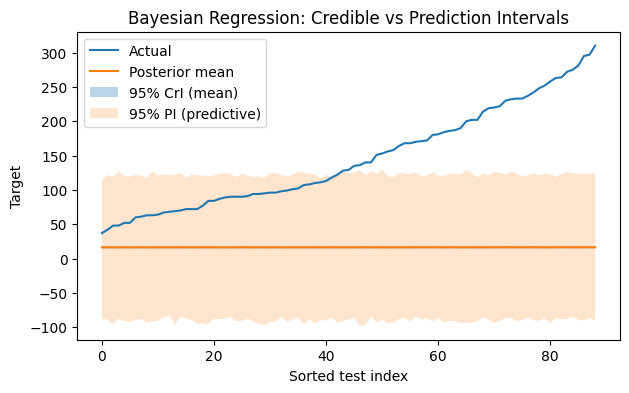

In [25]:
# Visualize uncertainty on a sorted index for readability
import matplotlib.pyplot as plt
import numpy as np

idx = np.argsort(y_test)
y_sorted = y_test[idx]
y_mean_sorted = y_mean_post[idx]
ci_lo_s, ci_hi_s = ci_lo[idx], ci_hi[idx]
pi_lo_s, pi_hi_s = pi_lo[idx], pi_hi[idx]

plt.figure(figsize=(7,4))
plt.plot(y_sorted, label="Actual")
plt.plot(y_mean_sorted, label="Posterior mean")
plt.fill_between(range(len(y_sorted)), ci_lo_s, ci_hi_s, alpha=0.3, label="95% CrI (mean)")
plt.fill_between(range(len(y_sorted)), pi_lo_s, pi_hi_s, alpha=0.2, label="95% PI (predictive)")
plt.xlabel("Sorted test index")
plt.ylabel("Target")
plt.title("Bayesian Regression: Credible vs Prediction Intervals")
plt.legend()
plt.show()


## Bootstrap Approximation (Frequentist but Practical)

The **bootstrap** resamples the training data to mimic sampling variability:
1. Draw $B$ bootstrap datasets by sampling $n$ rows **with replacement**.
2. Fit an OLS model on each bootstrap sample.
3. Predict on the test set; take percentiles across predictions for **empirical prediction intervals**.

This is not Bayesian, but it often gives **similar intuition** about uncertainty without extra libraries.


In [26]:
# Bootstrap predictive intervals
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
import numpy as np

B = 200  # number of bootstrap replicates (increase if time allows)
preds = []

for b in range(B):
    Xb, yb = resample(X_train_i, y_train, replace=True, random_state=1234 + b)
    m = LinearRegression(fit_intercept=False)
    m.fit(Xb, yb)
    preds.append(m.predict(X_test_i))

preds = np.array(preds)  # shape (B, n_test)

def pct(a, q): return np.percentile(a, q, axis=0)
boot_lo, boot_hi = pct(preds, 2.5), pct(preds, 97.5)

# Coverage (how often true y lies within bootstrap interval)
boot_cov = np.mean((y_test >= boot_lo) & (y_test <= boot_hi))
print(f"Bootstrap approx. 95% interval coverage: {boot_cov*100:.1f}%")


Bootstrap approx. 95% interval coverage: 28.1%


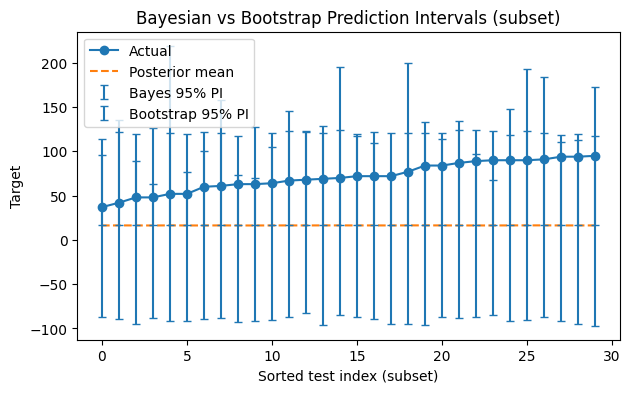

In [27]:
# Compare Bayesian PI vs Bootstrap intervals on a few points
import matplotlib.pyplot as plt
import numpy as np

k = min(30, len(y_test))  # plot first k sorted points for clarity
idx = np.argsort(y_test)[:k]

y_c = y_mean_post[idx]

# Bayes PI errors (ensure non-negative magnitudes)
bayes_lower = np.clip(y_c - pi_lo[idx], 0, None)
bayes_upper = np.clip(pi_hi[idx] - y_c, 0, None)
bayes_yerr = np.vstack([bayes_lower, bayes_upper])

# Bootstrap PI errors (ensure non-negative magnitudes)
boot_lower = np.clip(y_c - boot_lo[idx], 0, None)
boot_upper = np.clip(boot_hi[idx] - y_c, 0, None)
boot_yerr = np.vstack([boot_lower, boot_upper])

plt.figure(figsize=(7,4))
plt.plot(range(k), y_test[idx], label="Actual", marker='o')
plt.plot(range(k), y_c, label="Posterior mean", linestyle='--')

plt.errorbar(range(k), y_c, yerr=bayes_yerr, fmt='none', capsize=3, label="Bayes 95% PI")
plt.errorbar(range(k), y_c, yerr=boot_yerr,  fmt='none', capsize=3, label="Bootstrap 95% PI")

plt.xlabel("Sorted test index (subset)")
plt.ylabel("Target")
plt.title("Bayesian vs Bootstrap Prediction Intervals (subset)")
plt.legend()
plt.show()



## Confidence vs Credible Intervals (Recap)

- **Confidence interval (CI)**: frequency-based coverage under repeated sampling. It does **not** say "the parameter has 95% probability" in the interval.
- **Credible interval (CrI)**: posterior probability statement **given data and priors**. With a Gaussian prior and large $n$, CrIs often resemble CIs.

**Prediction intervals** include observation noise, hence are **wider** than intervals for the mean prediction.



## Exercises

1. **Prior sensitivity:** Change $\tau$ (e.g., 0.3, 1.0, 3.0). How do the credible and predictive intervals change? Report test $R^2$.
2. **Empirical Bayes for $\tau$:** Choose $\tau$ by 5‑fold CV, maximizing validation $R^2$ (hint: mimic Ridge search).
3. **Heteroscedasticity:** Replace constant $\sigma^2$ with a simple variance model $\sigma^2(x) = \sigma^2 (1 + \gamma |x^\top \beta|)$ and discuss the effect on intervals (simulation).
4. **Bootstrap size:** Increase $B$ to 1000 (if time allows). Do coverage and interval width stabilize?
